## Import and Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

# Load data
train = pd.read_csv('dataset\\train.csv')
test = pd.read_csv('dataset\\test.csv')

In [2]:
train

,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type,efficiency
0,0,7.817315,576.179270,41.24308670850264,32.135501,4.0,0.803199,37.403527,1.963787,13.691147,62.494044,12.82491203459621,1018.8665053152533,A1,NaN,NaN,0.562096
1,1,24.785727,240.003973,1.3596482765960705,19.977460,8.0,0.479456,21.843315,0.241473,27.545096,43.851238,12.012043660984917,1025.6238537572883,D4,E00,dual-axis,0.396447
2,2,46.652695,687.612799,91.26536837560256,1.496401,4.0,0.822398,48.222882,4.191800,43.363708,NaN,1.814399755560454,1010.9226539809573,C3,E00,NaN,0.573776
3,3,53.339567,735.141179,96.19095521176159,18.491582,3.0,0.837529,46.295748,0.960567,57.720436,67.361473,8.736258932034128,1021.8466633134253,A1,NaN,dual-axis,0.629009
4,4,5.575374,12.241203,27.495073003585226,30.722697,6.0,0.551833,0.000000,0.898062,6.786263,3.632000,0.52268384077164,1008.5559577591927,B2,E00,fixed,0.341874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,16.868428,NaN,93.53031757838667,14.393967,3.0,0.738911,12.147711,3.005355,26.206810,1.733013,12.594122273332914,1018.3744670739436,B2,E02,tracking,0.664907
19996,19996,53.415061,296.970303,93.98571391279083,25.997012,2.0,0.513061,0.000000,0.532119,65.000000,64.558667,0.9769909288128159,1016.081102065643,D4,E00,fixed,0.354070
19997,19997,2.442727,660.328019,37.9689180401391,32.818396,9.0,0.548602,13.047950,4.075498,11.584869,57.730134,4.750937249871706,1009.6844614602336,D4,NaN,tracking,0.419734
19998,19998,NaN,632.760700,43.01470184078199,19.063517,4.0,NaN,0.000000,1.068906,21.149351,78.123689,11.304158443374758,1006.6738746072241,A1,E00,tracking,0.661963


In [3]:
train.dtypes


id                      int64
temperature           float64
irradiance            float64
humidity               object
panel_age             float64
maintenance_count     float64
soiling_ratio         float64
voltage               float64
current               float64
module_temperature    float64
cloud_coverage        float64
wind_speed             object
pressure               object
string_id              object
error_code             object
installation_type      object
efficiency            float64
dtype: object

Here we get to know that some of the column has wrong data type so lets first handle it.

1. lets convert the string into float and round-of till 5 decimal.

In [5]:
# lets handle these value ['humidity', 'wind_speed', 'pressure']
# Now apply convert test and train into float and  check na value.

# 1. humidity contain (error, unknow and other strings as well.)
for col in ['humidity', 'wind_speed', 'pressure']: 
    # Step 1: Convert 'humidity' column to float
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(train[col], errors='coerce')

    # Step 2: Round the values to 5 decimal places
    train[col] = train[col].round(5)
    test[col] = test[col].round(5)


In [ ]:
print(test.isnull().sum().sort_values(ascending=False))
train.isnull().sum().sort_values(ascending=False)

error_code            3611
installation_type     2979
irradiance             615
soiling_ratio          610
maintenance_count      609
panel_age              607
current                587
temperature            582
cloud_coverage         582
module_temperature     580
voltage                547
humidity                83
pressure                79
wind_speed              69
id                       0
string_id                0
dtype: int64


error_code            5912
installation_type     5028
maintenance_count     1027
panel_age             1011
soiling_ratio         1010
cloud_coverage        1010
temperature           1001
voltage                993
irradiance             987
module_temperature     978
current                977
pressure               135
humidity               127
wind_speed             119
id                       0
string_id                0
efficiency               0
dtype: int64

In [7]:
zero_counts = (train == 0).sum().sort_values(ascending=False)
print("Number of zero values in each column:")
print(zero_counts)

Number of zero values in each column:
voltage               5158
efficiency             631
temperature            389
maintenance_count      349
module_temperature      20
id                       1
humidity                 0
panel_age                0
irradiance               0
current                  0
soiling_ratio            0
wind_speed               0
cloud_coverage           0
pressure                 0
string_id                0
error_code               0
installation_type        0
dtype: int64


In [10]:
train.dtypes
# Now it is corrected

id                      int64
temperature           float64
irradiance            float64
humidity              float64
panel_age             float64
maintenance_count     float64
soiling_ratio         float64
voltage               float64
current               float64
module_temperature    float64
cloud_coverage        float64
wind_speed            float64
pressure              float64
string_id              object
error_code             object
installation_type      object
efficiency            float64
dtype: object

In [11]:
train.describe()

,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,efficiency
count,20000.000000,18999.000000,19013.000000,19873.000000,18989.000000,18973.000000,18990.000000,19007.000000,19023.000000,19022.000000,18990.000000,19881.000000,19865.000000,20000.000000
mean,9999.500000,25.077241,501.273896,50.066170,17.509758,4.012070,0.698879,16.242251,1.713396,29.923807,51.378575,7.413226,1012.981286,0.510260
std,5773.647028,12.513129,250.926590,28.709656,10.097557,2.002268,0.172244,17.889031,1.152953,12.125405,48.473664,4.329861,10.046245,0.140420
min,0.000000,0.000000,-597.278646,0.010710,0.001264,0.000000,0.400149,0.000000,0.000054,0.000000,0.000244,0.001280,970.087370,0.000000
25%,4999.750000,16.853522,332.227277,25.273570,8.777905,3.000000,0.550654,0.000000,0.772311,21.522124,25.081618,3.668530,1006.187800,0.445613
50%,9999.500000,24.720345,499.654730,50.224150,17.497731,4.000000,0.697663,12.350138,1.558413,29.857669,49.704133,7.396090,1012.906120,0.515709
75%,14999.250000,32.848917,668.416734,74.513990,26.340761,5.000000,0.847838,26.557322,2.474744,38.094943,75.052824,11.158580,1019.786200,0.590324
max,19999.000000,147.394168,1537.810349,99.995200,34.998379,15.000000,0.999949,494.279016,7.315597,65.000000,1000.000000,14.999450,1052.865720,0.987066


In [51]:
# Select only numeric columns (float or int)
numeric_cols = train.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])

# Drop ID if it's just an identifier
numeric_cols = numeric_cols.drop(columns=['id'], errors='ignore')

# Compute correlation with 'efficiency'
eff_corr = numeric_cols.corr()['efficiency'].drop('efficiency').sort_values(key=abs, ascending=False)

# Show result
print("Correlation of features with efficiency:")
print(eff_corr)


Correlation of features with efficiency:
irradiance            0.778540
soiling_ratio         0.389938
current               0.362525
panel_age            -0.245398
voltage               0.164795
humidity             -0.086020
module_temperature   -0.065882
temperature          -0.057259
maintenance_count     0.017020
wind_speed           -0.009009
pressure             -0.004185
cloud_coverage       -0.003433
Name: efficiency, dtype: float64


## Need to handle Following things:
1. null value
2. 0 value
3. object into float and round off -> Handled above

In [ ]:
# Basic Obsevation on data set
print(test.isnull().sum().sort_values(ascending=False))
train.isnull().sum().sort_values(ascending=False)

error_code            3611
installation_type     2979
irradiance             615
soiling_ratio          610
maintenance_count      609
panel_age              607
current                587
temperature            582
cloud_coverage         582
module_temperature     580
voltage                547
humidity                83
pressure                79
wind_speed              69
id                       0
string_id                0
dtype: int64


error_code            5912
installation_type     5028
maintenance_count     1027
panel_age             1011
soiling_ratio         1010
cloud_coverage        1010
temperature           1001
voltage                993
irradiance             987
module_temperature     978
current                977
pressure               135
humidity               127
wind_speed             119
id                       0
string_id                0
efficiency               0
dtype: int64

## Data Cleaning

In [13]:
# Drop rows with 0 or missing efficiency
train = train[train['efficiency'] > 0].copy()
train.shape

(19369, 17)

#### Lets Clean categorical data first

In [50]:
for df in [test,train]:
    df['error_code'] = df['error_code'].fillna('Missing')
    df['installation_type'] = df['installation_type'].fillna('Unknown')
    
print(test["error_code"].isnull().sum())
print(train["error_code"].isnull().sum())


0
0


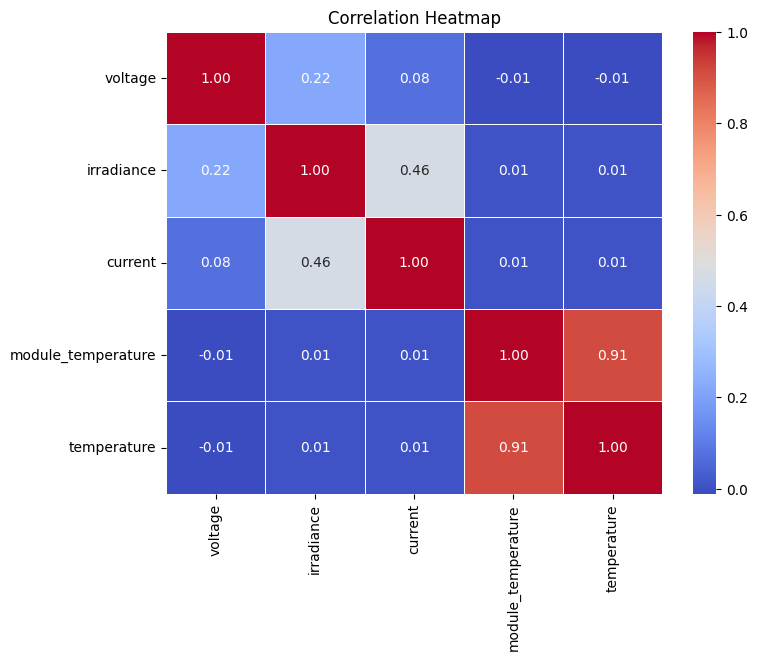

irradiance            0.220942
current               0.075383
module_temperature   -0.010874
temperature          -0.008661
Name: voltage, dtype: float64


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
corr_matrix = train[['voltage', 'irradiance', 'current', 'module_temperature', 'temperature']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()


# Get correlation with 'voltage' only, sorted by strength
voltage_corr = corr_matrix['voltage'].drop('voltage').sort_values(key=abs, ascending=False)
print(voltage_corr)


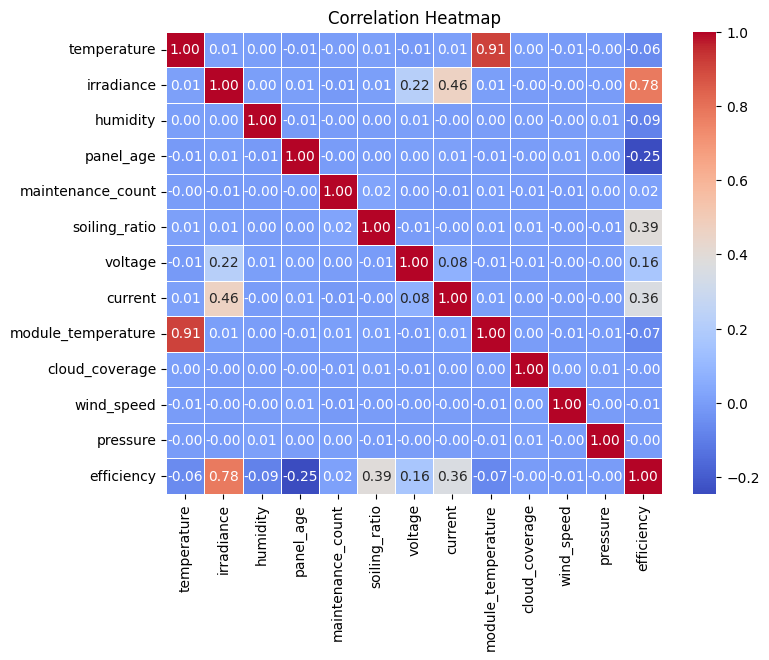

irradiance            0.220942
efficiency            0.164795
current               0.075383
module_temperature   -0.010874
temperature          -0.008661
soiling_ratio        -0.006063
humidity              0.005895
cloud_coverage       -0.005764
panel_age             0.004691
wind_speed           -0.003518
pressure             -0.002000
maintenance_count     0.001404
Name: voltage, dtype: float64


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
# Select only float columns
float_cols = train.select_dtypes(include=['float64', 'float32'])

# Calculate correlation matrix
corr_matrix = float_cols.corr()

# Get correlation with 'voltage' only, sorted by strength
voltage_corr = corr_matrix['voltage'].drop('voltage').sort_values(key=abs, ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()

print(voltage_corr)

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# Filter rows with valid voltage
valid_voltage = train[(train['voltage'] > 0) & (~train['voltage'].isna())].copy()

# Features to use
# ['voltage', 'irradiance', 'current', 'module_temperature', 'temperature']
features = ['irradiance', 'current', 'efficiency','temperature']

# Drop rows with NaN in these features
valid_voltage = valid_voltage.dropna(subset=features)

# Prepare data
X = valid_voltage[features]
y = valid_voltage['voltage']

# Train model
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X.shape)







'''Random forest was not giving good r2 value.'''
# voltage_model = RandomForestRegressor(n_estimators=100, random_state=42)
# voltage_model.fit(X_train, y_train)

# # Predict voltage for zero or missing values
# to_predict = train[(train['voltage'] == 0) | (train['voltage'].isna())]
# to_predict = to_predict.copy()

# # Prepare rows with complete features
# to_predict_clean = to_predict.dropna(subset=features)
# predicted_voltage = voltage_model.predict(to_predict_clean[features])

# # Fill back predicted values
# train.loc[to_predict_clean.index, 'voltage'] = predicted_voltage




(16625, 4)


'Random forest was not giving good r2 value.'

In [44]:
model = CatBoostRegressor(iterations=300, learning_rate=0.07, depth=5, random_seed=42, verbose=False)
model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
# Validation score
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)
print(r2)
print(f"RMSE: {rmse:.4f}")

0.06706308704758712
RMSE: 13.1006


In [22]:
valid_voltage

,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type,efficiency
0,0,7.817315,576.179270,41.24309,32.135501,4.0,0.803199,37.403527,1.963787,13.691147,62.494044,12.82491,1018.86651,A1,NaN,NaN,0.562096
1,1,24.785727,240.003973,1.35965,19.977460,8.0,0.479456,21.843315,0.241473,27.545096,43.851238,12.01204,1025.62385,D4,E00,dual-axis,0.396447
2,2,46.652695,687.612799,91.26537,1.496401,4.0,0.822398,48.222882,4.191800,43.363708,NaN,1.81440,1010.92265,C3,E00,NaN,0.573776
3,3,53.339567,735.141179,96.19096,18.491582,3.0,0.837529,46.295748,0.960567,57.720436,67.361473,8.73626,1021.84666,A1,NaN,dual-axis,0.629009
4,4,5.575374,12.241203,27.49507,30.722697,6.0,0.551833,17.588040,0.898062,6.786263,3.632000,0.52268,1008.55596,B2,E00,fixed,0.341874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19993,19993,25.855841,315.862679,5.01247,9.015300,2.0,0.571735,18.549739,0.713793,29.510798,68.449257,14.36801,1023.61884,D4,E00,dual-axis,0.451884
19994,19994,15.629977,258.801247,58.18878,NaN,3.0,0.660319,17.105855,0.215713,22.627634,1000.000000,14.99872,1022.49692,B2,E02,dual-axis,0.441625
19996,19996,53.415061,296.970303,93.98571,25.997012,2.0,0.513061,24.744985,0.532119,65.000000,64.558667,0.97699,1016.08110,D4,E00,fixed,0.354070
19997,19997,2.442727,660.328019,37.96892,32.818396,9.0,0.548602,13.047950,4.075498,11.584869,57.730134,4.75094,1009.68446,D4,NaN,tracking,0.419734


In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predict on validation set
y_pred = voltage_model.predict(X_val)

# R² Score
r2 = r2_score(y_val, y_pred)

# MAE, MSE, RMSE
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# this give very poor result for the prediction 

R² Score: -0.4446
MAE: 12.75
MSE: 327.66
RMSE: 18.10
